<a href="https://colab.research.google.com/github/ishatag/Data-Analysis-Project/blob/main/Assignment_Solution_Multi_Agent_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Agent Content Writer — LangGraph Assignment Sample Solution**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

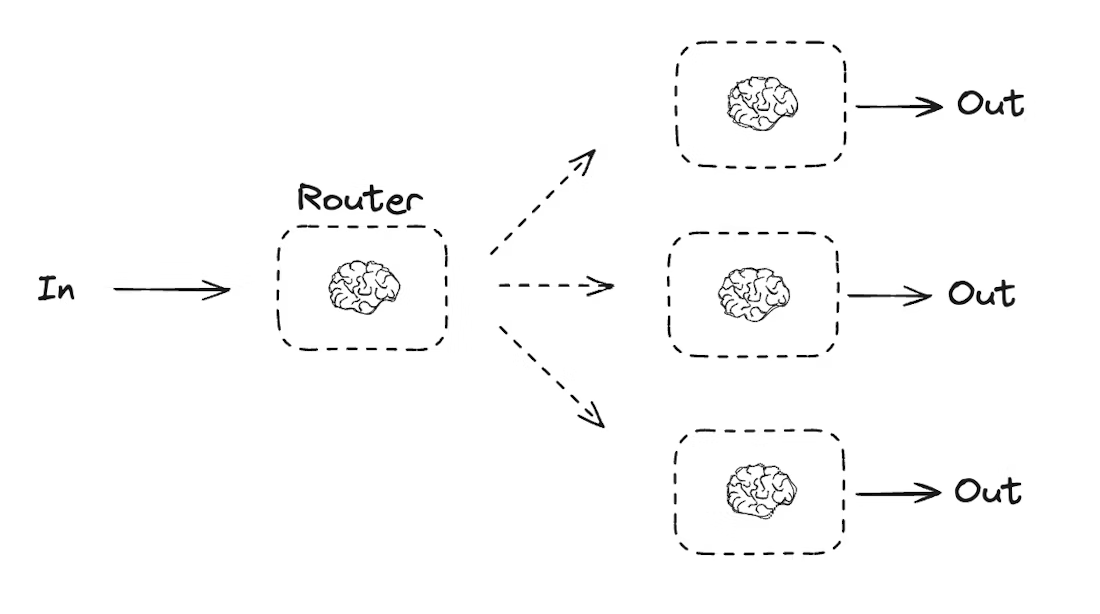




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Sample Solution Walkthrough**

## Necessary Imports

In [1]:
! pip install -q -U langgraph langchain langchain-openai deepagents

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.0/256.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.4/353.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.8/572.8 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.4/162.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.1/813.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268

## OpenAI API Key Setup

In [3]:
# Import API Keys

# Prompts the user for a password invisibly
import getpass

import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [27]:
#import API keys
import getpass

import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_APIKEY")
    os.environ["OPENAI_APIKEY"] = api_key_from_secrets
#os.environ['HOME'] (raises a KeyError if the variable does not exist).
#Keeping secret information (like database passwords or API tokens) out
# of your source code by loading them from your system or a .env file.

except:
       os.environ["OPEN_APIKEY"] = getpass.getpass("Enter your OpenAI API Key")

## Chat Model

In [4]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model= "gpt-4o-mini",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

## Define the State Class

In [5]:
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class CopyWriter(TypedDict):
  user_input: str           # The original user request
  route: Literal["seo_blog_writer", "x_blog_writer", "general"]  # Router's decision
  output: str               # Final output from the selected agent
  messages: Annotated[list[BaseMessage], add_messages]
##State = the shared memory/data that moves through your LangGraph.


## Define Router Node

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [12]:
router_instrunctions = """
  You are a smart router. Your job is to classify the user's request.

  If the user wants a long-form blog post, article, or detailed content → respond with: seo_blog_writer
  If the user wants a short tweet, X post, or social media content → respond with: x_blog_writer
  If the user's request is a general question, greeting, or anything NOT related to content writing → respond with: general

  Respond with ONLY one word: either seo_blog_writer, x_blog_writer, or general"""

In [13]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

def router_node(state: CopyWriter):
    messages = [
        SystemMessage(content=router_instrunctions),
        HumanMessage(content=state["user_input"])
    ]
    result = llm.invoke(messages)
    route = result.content.strip().lower()

    # Persist user input into messages for history tracking
    return {
        "route": route,
        "messages": [HumanMessage(content=state["user_input"])]
    }

In [14]:
# Test the router
test_cases = [
    "Write a detailed blog post about AI in healthcare",
    "Write a tweet about our new product launch",
    "Create an in-depth article on climate change",
    "Make a short X post announcing our funding round",
    "Hi, how are you?",
]

In [15]:
for test in test_cases:
    state = {"user_input": test, "route": "", "output": ""}
    result = router_node(state)
    print(f"Input: {test}\nRoute: {result['route']}\n")

# for — tells Python to repeat an action for each item.
#test — a variable that temporarily holds the current item. You could name it item or x instead.
#in — tells Python where to get the items from.
#test_cases — the list or collection you want to go through.
#  : — indicates that the loop's body starts on the next indented line.

Input: Write a detailed blog post about AI in healthcare
Route: seo_blog_writer

Input: Write a tweet about our new product launch
Route: x_blog_writer

Input: Create an in-depth article on climate change
Route: seo_blog_writer

Input: Make a short X post announcing our funding round
Route: x_blog_writer

Input: Hi, how are you?
Route: general



## Define General Node

In [10]:
# General node — router handles it directly

def general_node(state: CopyWriter):
    # Build conversation history from persisted messages
    history = state.get("messages", [])

    system = SystemMessage(content="""You are a helpful assistant. You have access to the full conversation history.
    Answer the user's question briefly and clearly using context from previous messages if relevant.
    Let them know you specialize in SEO blog writing and X/Twitter post writing if they need content.""")

    # Add current user input to history
    messages = [system] + history + [HumanMessage(content=state["user_input"])]

    result = llm.invoke(messages)

    # Save to messages so checkpointer persists it
    return {
        "output": result.content,
        "messages": [
            HumanMessage(content=state["user_input"]),
            AIMessage(content=result.content)
        ]
    }

## Define SEO Blog Writer Node

#### Internet Search Tool

In [16]:
!pip install -q  tavily-python langchain-tavily

In [17]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [18]:
# Import API Keys

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

Enter your Tavily API key: ··········


In [19]:
# Create Internet Search vis TavilySearch

from langchain_tavily import TavilySearch

internet_search = TavilySearch(
    max_results=10,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
    # time_range="day",
    #include_domains=None,
    # exclude_domains=None
)

In [20]:
# Test internet_search
internet_search.invoke({"query": "Top 5 global news as of today"})

{'query': 'Top 5 global news as of today',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=122267777108134472',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3999805433467975459',
   'title': "Check out the day's top headlines. 📰☕ Do not forget to stay informed  through our social networks and our website: www.telesurenglish.net #News  #Headlines #TopNews #NewsBits #teleSUREnglish",
   'description': None},
  {'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=122303870846134472',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://s1.dmcdn.net/v/b1AfY1g1dCucxdGsZ/x360',
   'title': 'Today’s Top World News Headlines — May 15, 2026',
   'description': 'The image displays a li

#### Deep Content Reserach SubAgent


In [21]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [22]:
# Define Model for Deep Research Agent
model = init_chat_model(model="gpt-4o-mini", model_provider="openai", temperature=0.2)

In [23]:
deep_research_instructions = """You are a professional content researcher specializing in deep topic research for blog writing. Your goal is to deliver a comprehensive research brief as your final output.

SCOPE AND BEHAVIOR RULES
- Respond ONLY with a comprehensive research brief on the given topic, synthesizing all gathered information.
- Gather key facts, statistics, expert opinions, and trending angles.
- If the topic is unclear, state assumptions and proceed.

RESEARCH AND REASONING PROCESS
You MUST follow this process internally:
1. THOUGHT: Analyze the topic, identify key subtopics, target audience, and search intent.
2. ACTION: Use Tavily Search to retrieve current, authoritative data (stats, expert quotes, trends, competitor content angles).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty.
4. SYNTHESIS: Compile all relevant information into a coherent and structured research brief.
5. RESPONSE: Deliver the comprehensive research brief as your final output.

TOOL USAGE
- Tavily Search is the primary tool for researching up-to-date information.
- Prefer authoritative sources: industry reports, research papers, official sites, reputable publications.
- Do not fabricate details; explicitly state gaps.

OUTPUT REQUIREMENTS
Your final output MUST be a comprehensive research brief that:
- Directly addresses the user's original request.
- Includes a clear topic overview and search intent analysis.
- Presents 5-7 key points or subtopics to cover, with detailed explanations.
- Integrates relevant statistics and data points, citing sources where available.
- Highlights trending angles or unique perspectives.
- Identifies potential competitor content gaps.
- Is formatted clearly and professionally.

QUALITY BAR
- Prioritize accuracy and recency of information.
- Focus on what will make the content valuable and comprehensive.
- Flag any conflicting information found during research.
"""

In [24]:
content_research_agent = create_deep_agent(
    model=model,
    system_prompt=deep_research_instructions,
    tools=[internet_search],
)

In [25]:
result = content_research_agent.invoke({"messages": [{"role": "user", "content": "Rserach content for a blog on Employee productivity with Claude Code"}]})

print(result)

{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='1c097594-9ab1-4acc-93aa-39e48115069f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 3533, 'total_tokens': 3558, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_10b7343b83', 'id': 'chatcmpl-EWp0KzPsRYBxC0HOU2uJEO0sa7053', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a11d33-4b82-7831-b1c6-53c2c32df236-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Employee productivity with Claude Code', 'search_depth': 'advance

In [ ]:
# Print the agent's response
print(result["messages"][-1].content)

## Research Brief: Employee Productivity with Claude Code (Anthropic)  
**Assumptions:** You want a blog aimed at business/tech leaders and practitioners explaining how *Claude Code* (Anthropic’s agentic coding tool) can raise employee productivity—primarily for engineering teams, but also adjacent technical roles (data, product, operations). If you meant “Claude *AI*” broadly (not Claude Code), the structure still works, but examples and tactics would expand beyond software work.

---

## 1) Topic overview (what the post should cover)
Claude Code is an **agentic coding assistant** that can **read a codebase, edit files, run commands/tests, and iterate**—available via **terminal CLI, IDE integrations, desktop app, and web**. The productivity story is less about “typing faster” and more about:  
- reducing time spent on **context gathering** (finding relevant files, understanding systems)  
- accelerating **multi-step implementation** (edit → run → test → fix loops)  
- enabling employe

In [ ]:
print(result)

{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='b1cdf40f-c00e-4bf7-b81d-2423b5929417'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 215, 'prompt_tokens': 6606, 'total_tokens': 6821, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DEoyM1W20kSyeQd4ACgKm7i2uYE4g', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cacc1-b686-70f0-b471-31eaed03e80b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Claude Code employee productivity use cases', 'search_depth': 'advanced', 'time_range': 'year', 'topic': 'g

In [26]:
query = "Research content for a blog on Employee productivity with Claude Code"

for event in content_research_agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='Research content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='f781fd95-95bd-4dab-89c5-a8b0949abf60')], 'files': {}}
================================ Human Message =================================

Research content for a blog on Employee productivity with Claude Code
{'messages': [HumanMessage(content='Research content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='f781fd95-95bd-4dab-89c5-a8b0949abf60'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 3531, 'total_tokens': 3556, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2816}}, 'model_provider': 'openai', 'model_name':

#### Content Reserach Agent as a Tool

In [28]:
# Defining content_research_agent as a Tool

from langchain_core.tools import tool

@tool("content_research_agent", description="plans blog content")
def call_content_research_agent(query: str):
    result = content_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

In [29]:
tools = [call_content_research_agent, internet_search]

#### SEO Blog Writer Node

In [30]:
# Bind tools to LLM for the SEO agent
blog_writer_with_tools = llm.bind_tools(tools)

In [31]:
seo_blog_instructions = """
You are an expert SEO blog writer with access to tools.

You have two tools:
1. research_tool — Use this to find content, references, and insights to enrich the blog.
2. internet_search_tool — Use this to check SEO keywords, trending terms, and optimize content.

Workflow:
- First, use research_tool to gather relevant content.
- Then, use internet_search_tool to find the best SEO keywords.
- Finally, write a well-structured, keyword-optimized blog post.

Include: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.
"""

In [32]:
# SEO blog writer — uses messages for tool loop
def seo_blog_writer_node(state: CopyWriter):
    # First call: seed messages from user_input
    if not state.get("messages"):
        messages = [
            SystemMessage(content=seo_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = blog_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

## Define X Blog Writer Node

In [34]:
# X Blog Writer with tools
x_blog_instructions = """
You are an expert X (Twitter) content writer with access to tools.

You have one tool:
1. internet_search_tool — Use this to find trending topics, viral headlines, and popular hashtags related to the user's request.

Workflow:
- First, use internet_search_tool to find trending topics and hashtags.
- Then, write an engaging, viral-worthy X post using those insights.

Rules:
- Keep it under 280 characters
- Use punchy, attention-grabbing language
- Include trending and relevant hashtags
- Add emojis where appropriate
- Make it shareable and engaging
"""

In [35]:
x_tools = [internet_search]
x_writer_with_tools = llm.bind_tools(x_tools)

In [36]:
# X blog writer — uses messages for tool loop
def x_blog_writer_node(state: CopyWriter):
    if not state.get("messages"):
        messages = [
            SystemMessage(content=x_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = x_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

## Define Tool Nodes

In [37]:
# Tool nodes
from langgraph.prebuilt import ToolNode

seo_tool_node = ToolNode(tools=tools)
x_tool_node = ToolNode(tools=x_tools)

## Define Conditional Edges

In [38]:
# Conditional edges — check if agent wants more tools or is done
def seo_should_continue(state: CopyWriter):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "end"

def x_should_continue(state: CopyWriter):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "x_tools"
    return "end"

def route_decision(state: CopyWriter):
    return state["route"]

## Build Graph

In [39]:
# Build the graph
from langgraph.graph import StateGraph
from langgraph.graph.state import END

workflow = StateGraph(CopyWriter)

workflow.add_node("router", router_node)
workflow.add_node("seo_blog_writer", seo_blog_writer_node)
workflow.add_node("x_blog_writer", x_blog_writer_node)
workflow.add_node("tools", seo_tool_node)
workflow.add_node("x_tools", x_tool_node)
workflow.add_node("general", general_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges("router", route_decision, {
    "seo_blog_writer": "seo_blog_writer",
    "x_blog_writer": "x_blog_writer",
    "general": "general",
})

# SEO agent ↔ tools loop
workflow.add_conditional_edges("seo_blog_writer", seo_should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "seo_blog_writer")

# X agent ↔ tools loop
workflow.add_conditional_edges("x_blog_writer", x_should_continue, {"x_tools": "x_tools", "end": END})
workflow.add_edge("x_tools", "x_blog_writer")

# General → END
workflow.add_edge("general", END)

## Persistence & Compile

In [40]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = workflow.compile(checkpointer=memory)

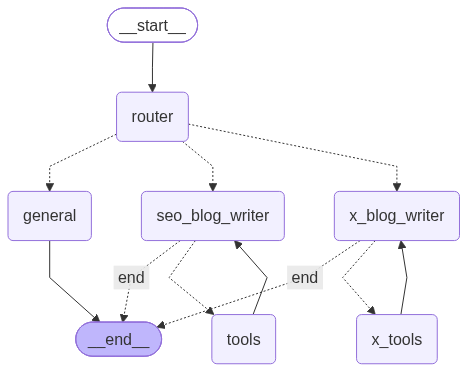

In [41]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## Test Multi-Agent Copywriter

In [42]:
config = {"configurable": {"thread_id": "session-1"}}

In [43]:
# Test 1: SEO Blog
print("=" * 60)
print("TEST 1: SEO BLOG REQUEST")
print("=" * 60)

input_1 = {"user_input": "Write a detailed blog post about AI in healthcare", "route": "", "output": "", "messages": []}

for step in graph.stream(input_1, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 1: SEO BLOG REQUEST

--- Node: router ---
🧭 Route: seo_blog_writer

--- Node: seo_blog_writer ---
🤖 Agent requesting: content_research_agent({'query': 'AI in healthcare'})

--- Node: tools ---
🔧 Tool Result: # Comprehensive Research Brief: AI in Healthcare

## Topic Overview
Artificial Intelligence (AI) in healthcare refers to the application of AI technologies to enhance various aspects of medical practice, including diagnostics, treatment planning, patient monitoring, and operational efficiency. The integration of AI is reshaping healthcare delivery, improving patient outcomes, and streamlining administrative processes. This brief explores the current landscape, applications, benefits, challenges, and future trends of AI in healthcare.

## Search Intent Analysis
The intent behind researching AI in healthcare typically includes:
- Understanding the applications and benefits of AI technologies in medical settings.
- Exploring current trends and future developments in AI healthcare

In [44]:
# Test 2: X Post
print("=" * 60)
print("TEST 2: X POST REQUEST")
print("=" * 60)

input_2 = {"user_input": "Write a tweet about our new product launch", "route": "", "output": "", "messages": []}

for step in graph.stream(input_2, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")


TEST 2: X POST REQUEST

--- Node: router ---
🧭 Route: x_blog_writer

--- Node: x_blog_writer ---
✅ Final Output:
🚀 Exciting news! We're thrilled to announce the launch of our latest product, designed to revolutionize your experience! 🎉 Stay tuned for more details and get ready to elevate your game! #NewLaunch #Innovation #StayTuned...


In [45]:
# Test 3:
print("=" * 60)
print("TEST 3")
print("=" * 60)

input_3 = {"user_input": "What was my recent ask?", "route": "", "output": "", "messages": []}

for step in graph.stream(input_3, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 3

--- Node: router ---
🧭 Route: general

--- Node: general ---
✅ Final Output:
Your recent ask was to write a tweet about your new product launch....


In [47]:
# Test 4: SEO Blog
#from my side
print("=" * 60)
print("TEST 4: SEO BLOG REQUEST")
print("=" * 60)

input_1 = {"user_input": "Write a detailed blog post about gen z protests across the world in 2026", "route": "", "output": "", "messages": []}

for step in graph.stream(input_1, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 4: SEO BLOG REQUEST

--- Node: router ---
🧭 Route: seo_blog_writer

--- Node: seo_blog_writer ---
🤖 Agent requesting: tavily_search({'query': 'Gen Z protests across the world 2026'})

--- Node: tools ---
🔧 Tool Result: {"query": "Gen Z protests across the world 2026", "follow_up_questions": null, "answer": null, "images": [{"url": "https://static01.nyt.com/images/2026/04/08/multimedia/08int-genz-protests-01-zvhc/08int-genz-protests-01-zvhc-articleLarge.jpg?quality=75&auto=avif&disable=upscale", "title": "How Gen Z Protests Have Fared Around the World - The New York Times", "description": "A large group of Gen Z protesters, mostly young people, are gathered outdoors, some smiling and waving, holding signs and wearing casual clothing and baseball caps."}, {"url": "http://cdn.statcdn.com/Infographic/images/normal/35230.jpeg", "title": "Chart: Where Gen Z Protests Are Rocking the World | Statista", "description": "The image shows a world map highlighting countries where large-scale yo